In [1]:
# Import libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation, LabelSpreading
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('..')
from src.models.semi_supervised import SemiSupervisedClassifier
from src.visualization.plots import Visualizer

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
# Load features
print("="*60)
print("LOADING FEATURES")
print("="*60)

X_train = np.load('../data/processed/features/X_train_combined.npy')
y_train = np.load('../data/processed/features/y_train.npy')
X_test = np.load('../data/processed/features/X_test_combined.npy')
y_test = np.load('../data/processed/features/y_test.npy')

print(f"📊 Training features shape: {X_train.shape}")
print(f"📊 Test features shape: {X_test.shape}")
print(f"📊 Training labels shape: {y_train.shape}")
print(f"📊 Test labels shape: {y_test.shape}")

# Combine for semi-supervised experiments
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])

print(f"\n📊 Combined data shape: {X.shape}")
print(f"📊 Combined labels shape: {y.shape}")

LOADING FEATURES
📊 Training features shape: (10000, 5100)
📊 Test features shape: (2000, 5100)
📊 Training labels shape: (10000,)
📊 Test labels shape: (2000,)



📊 Combined data shape: (12000, 5100)
📊 Combined labels shape: (12000,)


In [3]:
# Create function to generate limited labels
print("="*60)
print("CREATING LIMITED LABELS")
print("="*60)

def create_limited_labels(y, labeled_percent, random_state=42):
    """Create limited labels by masking most labels"""
    y_limited = y.copy().astype(float)
    
    # Number of labeled samples per class
    n_labeled = int(len(y) * labeled_percent / 100)
    
    np.random.seed(random_state)
    
    # Randomly select indices to keep labeled
    all_indices = np.arange(len(y))
    labeled_indices = np.random.choice(all_indices, n_labeled, replace=False)
    
    # Set others to -1 (unlabeled)
    mask = np.ones(len(y), dtype=bool)
    mask[labeled_indices] = False
    y_limited[mask] = -1
    
    return y_limited, labeled_indices

# Test with different percentages
percentages = [5, 10, 20, 30, 50]

for pct in percentages:
    y_limited, labeled_idx = create_limited_labels(y, pct, random_state=42)
    n_labeled = np.sum(y_limited != -1)
    n_unlabeled = np.sum(y_limited == -1)
    
    print(f"\n📊 {pct}% labeled:")
    print(f"  • Labeled: {n_labeled:,} samples")
    print(f"  • Unlabeled: {n_unlabeled:,} samples")
    print(f"  • Actual %: {n_labeled/len(y)*100:.1f}%")

CREATING LIMITED LABELS

📊 5% labeled:
  • Labeled: 600 samples
  • Unlabeled: 11,400 samples
  • Actual %: 5.0%

📊 10% labeled:
  • Labeled: 1,200 samples
  • Unlabeled: 10,800 samples
  • Actual %: 10.0%

📊 20% labeled:
  • Labeled: 2,400 samples
  • Unlabeled: 9,600 samples
  • Actual %: 20.0%

📊 30% labeled:
  • Labeled: 3,600 samples
  • Unlabeled: 8,400 samples
  • Actual %: 30.0%

📊 50% labeled:
  • Labeled: 6,000 samples
  • Unlabeled: 6,000 samples
  • Actual %: 50.0%


In [4]:
# Self-Training experiment
print("="*60)
print("SELF-TRAINING EXPERIMENT")
print("="*60)

results_self = []

for pct in percentages:
    print(f"\n{'='*40}")
    print(f"📊 Labeled: {pct}%")
    print(f"{'='*40}")
    
    # Create limited labels
    y_limited, labeled_idx = create_limited_labels(y, pct, random_state=42)
    
    # Split into train/test (use all data, but only labeled for evaluation)
    X_train_ss, X_test_ss, y_limited_train, y_limited_test, y_train_full, y_test_full = train_test_split(
        X, y_limited, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Base estimator
    base_estimator = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    
    # Self-training
    self_model = SelfTrainingClassifier(base_estimator, threshold=0.75, max_iter=100)
    self_model.fit(X_train_ss, y_limited_train)
    
    # Predict on test
    y_pred_self = self_model.predict(X_test_ss)
    
    # Filter out unlabeled in test
    test_labeled_mask = y_limited_test != -1
    if np.any(test_labeled_mask):
        y_test_filtered = y_test_full[test_labeled_mask]
        y_pred_filtered = y_pred_self[test_labeled_mask]
        accuracy_self = accuracy_score(y_test_filtered, y_pred_filtered)
        f1_self = f1_score(y_test_filtered, y_pred_filtered, average='macro')
    else:
        accuracy_self = accuracy_score(y_test_full, y_pred_self)
        f1_self = f1_score(y_test_full, y_pred_self, average='macro')
    
    # Supervised baseline (only on labeled data)
    train_labeled_mask = y_limited_train != -1
    if np.any(train_labeled_mask):
        X_train_labeled = X_train_ss[train_labeled_mask]
        y_train_labeled = y_limited_train[train_labeled_mask].astype(int)
        
        supervised_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        supervised_model.fit(X_train_labeled, y_train_labeled)
        
        y_pred_sup = supervised_model.predict(X_test_ss)
        accuracy_sup = accuracy_score(y_test_full, y_pred_sup)
        f1_sup = f1_score(y_test_full, y_pred_sup, average='macro')
    else:
        accuracy_sup = 0
        f1_sup = 0
    
    # Count pseudo-labels
    n_pseudo = np.sum((y_limited_train == -1) & (self_model.transduction_ != -1))
    
    results_self.append({
        'labeled_percent': pct,
        'method': 'self-training',
        'accuracy': accuracy_self,
        'f1': f1_self,
        'supervised_accuracy': accuracy_sup,
        'supervised_f1': f1_sup,
        'improvement': f1_self - f1_sup,
        'pseudo_labels': n_pseudo,
        'iterations': self_model.n_iter_
    })
    
    print(f"\n📊 Results:")
    print(f"  • Self-training F1: {f1_self:.4f}")
    print(f"  • Supervised F1: {f1_sup:.4f}")
    print(f"  • Improvement: {f1_self - f1_sup:+.4f}")
    print(f"  • Pseudo-labels added: {n_pseudo}")
    print(f"  • Iterations: {self_model.n_iter_}")

results_self_df = pd.DataFrame(results_self)
print("\n📊 Self-Training Results Summary:")
print(results_self_df.to_string())

SELF-TRAINING EXPERIMENT

📊 Labeled: 5%



📊 Results:
  • Self-training F1: 0.7347
  • Supervised F1: 0.7547
  • Improvement: -0.0201
  • Pseudo-labels added: 7945
  • Iterations: 9

📊 Labeled: 10%



📊 Results:
  • Self-training F1: 0.7677
  • Supervised F1: 0.7621
  • Improvement: +0.0056
  • Pseudo-labels added: 7178
  • Iterations: 19

📊 Labeled: 20%



📊 Results:
  • Self-training F1: 0.7826
  • Supervised F1: 0.7857
  • Improvement: -0.0031
  • Pseudo-labels added: 6023
  • Iterations: 19

📊 Labeled: 30%



📊 Results:
  • Self-training F1: 0.8146
  • Supervised F1: 0.7991
  • Improvement: +0.0156
  • Pseudo-labels added: 4953
  • Iterations: 13

📊 Labeled: 50%



📊 Results:
  • Self-training F1: 0.7890
  • Supervised F1: 0.8016
  • Improvement: -0.0126
  • Pseudo-labels added: 3173
  • Iterations: 10

📊 Self-Training Results Summary:
   labeled_percent         method  accuracy        f1  supervised_accuracy  supervised_f1  improvement  pseudo_labels  iterations
0                5  self-training  0.735294  0.734657             0.755833       0.754743    -0.020087           7945           9
1               10  self-training  0.769231  0.767690             0.762500       0.762053     0.005636           7178          19
2               20  self-training  0.782609  0.782605             0.785833       0.785717    -0.003112           6023          19
3               30  self-training  0.814661  0.814644             0.799167       0.799065     0.015579           4953          13
4               50  self-training  0.789037  0.788978             0.801667       0.801566    -0.012588           3173          10


In [5]:
# Label Propagation experiment
print("="*60)
print("LABEL PROPAGATION EXPERIMENT")
print("="*60)

results_prop = []

for pct in percentages:
    print(f"\n{'='*40}")
    print(f"📊 Labeled: {pct}%")
    print(f"{'='*40}")
    
    # Create limited labels
    y_limited, labeled_idx = create_limited_labels(y, pct, random_state=42)
    
    # Split into train/test
    X_train_ss, X_test_ss, y_limited_train, y_limited_test, y_train_full, y_test_full = train_test_split(
        X, y_limited, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Label Propagation
    prop_model = LabelPropagation(kernel='knn', n_neighbors=7)
    prop_model.fit(X_train_ss, y_limited_train)
    
    # Predict on test
    y_pred_prop = prop_model.predict(X_test_ss)
    
    # Filter out unlabeled in test
    test_labeled_mask = y_limited_test != -1
    if np.any(test_labeled_mask):
        y_test_filtered = y_test_full[test_labeled_mask]
        y_pred_filtered = y_pred_prop[test_labeled_mask]
        accuracy_prop = accuracy_score(y_test_filtered, y_pred_filtered)
        f1_prop = f1_score(y_test_filtered, y_pred_filtered, average='macro')
    else:
        accuracy_prop = accuracy_score(y_test_full, y_pred_prop)
        f1_prop = f1_score(y_test_full, y_pred_prop, average='macro')
    
    # Supervised baseline
    train_labeled_mask = y_limited_train != -1
    if np.any(train_labeled_mask):
        X_train_labeled = X_train_ss[train_labeled_mask]
        y_train_labeled = y_limited_train[train_labeled_mask].astype(int)
        
        supervised_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        supervised_model.fit(X_train_labeled, y_train_labeled)
        
        y_pred_sup = supervised_model.predict(X_test_ss)
        accuracy_sup = accuracy_score(y_test_full, y_pred_sup)
        f1_sup = f1_score(y_test_full, y_pred_sup, average='macro')
    else:
        accuracy_sup = 0
        f1_sup = 0
    
    results_prop.append({
        'labeled_percent': pct,
        'method': 'label_propagation',
        'accuracy': accuracy_prop,
        'f1': f1_prop,
        'supervised_accuracy': accuracy_sup,
        'supervised_f1': f1_sup,
        'improvement': f1_prop - f1_sup
    })

results_prop_df = pd.DataFrame(results_prop)
print("\n📊 Label Propagation Results Summary:")
print(results_prop_df.to_string())

LABEL PROPAGATION EXPERIMENT

📊 Labeled: 5%



📊 Labeled: 10%



📊 Labeled: 20%



📊 Labeled: 30%



📊 Labeled: 50%



📊 Label Propagation Results Summary:
   labeled_percent             method  accuracy        f1  supervised_accuracy  supervised_f1  improvement
0                5  label_propagation  0.666667  0.658258             0.755833       0.754743    -0.096486
1               10  label_propagation  0.642534  0.641477             0.762500       0.762053    -0.120576
2               20  label_propagation  0.684783  0.684662             0.785833       0.785717    -0.101055
3               30  label_propagation  0.681881  0.681744             0.799167       0.799065    -0.117321
4               50  label_propagation  0.698505  0.698005             0.801667       0.801566    -0.103561


LEARNING CURVES


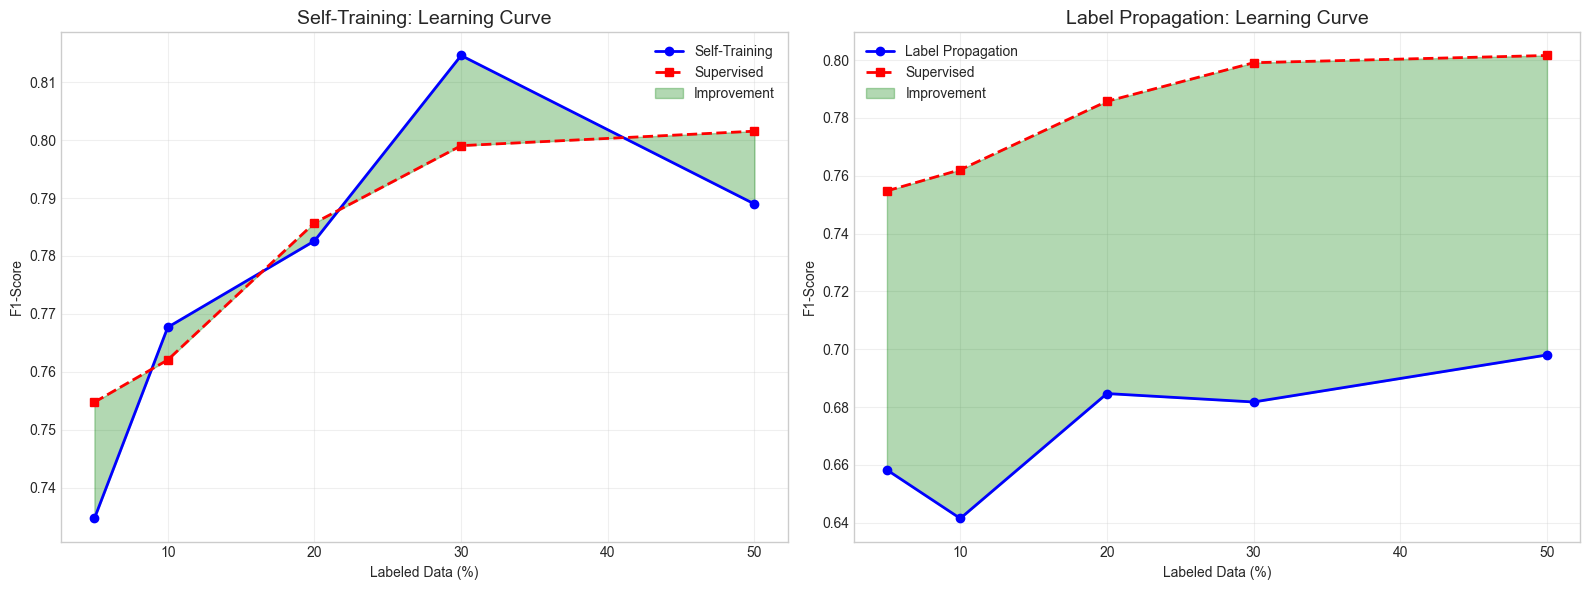

In [6]:
# Plot learning curves
print("="*60)
print("LEARNING CURVES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Self-training curve
ax = axes[0]
ax.plot(results_self_df['labeled_percent'], results_self_df['f1'], 
        'b-o', label='Self-Training', linewidth=2)
ax.plot(results_self_df['labeled_percent'], results_self_df['supervised_f1'], 
        'r--s', label='Supervised', linewidth=2)
ax.fill_between(results_self_df['labeled_percent'], 
                results_self_df['supervised_f1'], 
                results_self_df['f1'],
                alpha=0.3, color='green', label='Improvement')
ax.set_xlabel('Labeled Data (%)')
ax.set_ylabel('F1-Score')
ax.set_title('Self-Training: Learning Curve', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Label Propagation curve
ax = axes[1]
ax.plot(results_prop_df['labeled_percent'], results_prop_df['f1'], 
        'b-o', label='Label Propagation', linewidth=2)
ax.plot(results_prop_df['labeled_percent'], results_prop_df['supervised_f1'], 
        'r--s', label='Supervised', linewidth=2)
ax.fill_between(results_prop_df['labeled_percent'], 
                results_prop_df['supervised_f1'], 
                results_prop_df['f1'],
                alpha=0.3, color='green', label='Improvement')
ax.set_xlabel('Labeled Data (%)')
ax.set_ylabel('F1-Score')
ax.set_title('Label Propagation: Learning Curve', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

IMPROVEMENT ANALYSIS

📊 Improvement by method (% points):
method           Label Propagation  Self-Training
labeled_percent                                  
5                        -0.096486      -0.020087
10                       -0.120576       0.005636
20                       -0.101055      -0.003112
30                       -0.117321       0.015579
50                       -0.103561      -0.012588


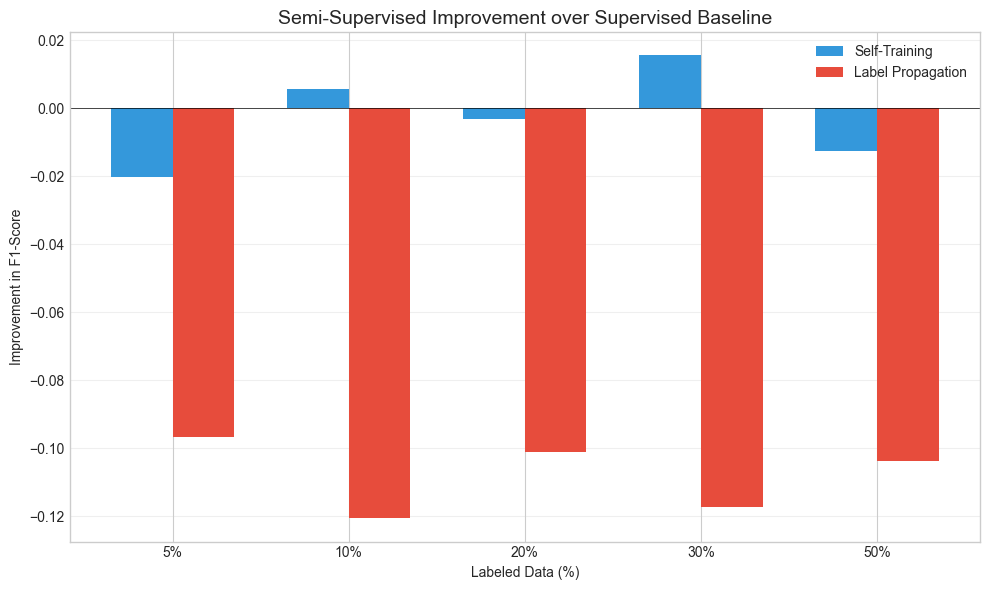


📊 Best improvement:
  • Self-Training: 0.0156 at 30% labeled
  • Label Propagation: -0.0965 at 5% labeled


In [7]:
# Analyze improvement
print("="*60)
print("IMPROVEMENT ANALYSIS")
print("="*60)

# Combine results
results_self_df['method'] = 'Self-Training'
results_prop_df['method'] = 'Label Propagation'
combined_results = pd.concat([results_self_df, results_prop_df])

# Pivot for comparison
pivot = combined_results.pivot(index='labeled_percent', columns='method', values='improvement')
print("\n📊 Improvement by method (% points):")
print(pivot)

# Visualize improvement
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(percentages))
width = 0.35

ax.bar(x - width/2, results_self_df['improvement'], width, 
       label='Self-Training', color='#3498db')
ax.bar(x + width/2, results_prop_df['improvement'], width, 
       label='Label Propagation', color='#e74c3c')

ax.set_xlabel('Labeled Data (%)')
ax.set_ylabel('Improvement in F1-Score')
ax.set_title('Semi-Supervised Improvement over Supervised Baseline', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f"{p}%" for p in percentages])
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Best improvement:")
best_self = results_self_df.loc[results_self_df['improvement'].idxmax()]
best_prop = results_prop_df.loc[results_prop_df['improvement'].idxmax()]

print(f"  • Self-Training: {best_self['improvement']:.4f} at {best_self['labeled_percent']:.0f}% labeled")
print(f"  • Label Propagation: {best_prop['improvement']:.4f} at {best_prop['labeled_percent']:.0f}% labeled")

In [8]:
# Analyze pseudo-label quality
print("="*60)
print("PSEUDO-LABEL QUALITY ANALYSIS")
print("="*60)

# Use 20% labeled for detailed analysis
pct = 20
y_limited, labeled_idx = create_limited_labels(y, pct, random_state=42)

# Split
X_train_ss, X_test_ss, y_limited_train, y_limited_test, y_train_full, y_test_full = train_test_split(
    X, y_limited, y, test_size=0.2, random_state=42, stratify=y
)

# Train self-training
base_estimator = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
self_model = SelfTrainingClassifier(base_estimator, threshold=0.75, max_iter=100)
self_model.fit(X_train_ss, y_limited_train)

# Identify pseudo-labeled samples
pseudo_mask = (y_limited_train == -1) & (self_model.transduction_ != -1)
pseudo_labels = self_model.transduction_[pseudo_mask]
pseudo_indices = np.where(pseudo_mask)[0]

# Get true labels for these samples
pseudo_true = y_train_full[pseudo_mask]

# Calculate accuracy of pseudo-labels
pseudo_accuracy = accuracy_score(pseudo_true, pseudo_labels)
pseudo_f1 = f1_score(pseudo_true, pseudo_labels, average='macro')

print(f"\n📊 Pseudo-label statistics for {pct}% labeled:")
print(f"  • Total pseudo-labels: {len(pseudo_labels)}")
print(f"  • Accuracy: {pseudo_accuracy:.4f}")
print(f"  • F1-score: {pseudo_f1:.4f}")

# Analyze by confidence (if available)
if hasattr(self_model, 'label_distributions_'):
    confidences = np.max(self_model.label_distributions_[pseudo_mask], axis=1)
    
    print(f"\n📊 Confidence distribution:")
    print(f"  • Mean confidence: {confidences.mean():.4f}")
    print(f"  • Median confidence: {np.median(confidences):.4f}")
    
    # Accuracy by confidence threshold
    print(f"\n📊 Accuracy by confidence threshold:")
    for threshold in [0.6, 0.7, 0.8, 0.9]:
        high_conf_mask = confidences >= threshold
        if np.sum(high_conf_mask) > 0:
            acc = accuracy_score(pseudo_true[high_conf_mask], pseudo_labels[high_conf_mask])
            print(f"  • Threshold {threshold:.1f}: {np.sum(high_conf_mask)} samples, acc={acc:.4f}")
    
    # Plot confidence distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of confidences
    ax = axes[0]
    ax.hist(confidences, bins=20, color='#3498db', alpha=0.7, edgecolor='black')
    ax.axvline(0.75, color='red', linestyle='--', label='Threshold (0.75)')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Frequency')
    ax.set_title('Pseudo-label Confidence Distribution')
    ax.legend()
    
    # Accuracy by confidence bin
    ax = axes[1]
    bins = np.linspace(0.5, 1.0, 6)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_accuracies = []
    
    for i in range(len(bins)-1):
        mask = (confidences >= bins[i]) & (confidences < bins[i+1])
        if np.sum(mask) > 0:
            acc = accuracy_score(pseudo_true[mask], pseudo_labels[mask])
            bin_accuracies.append(acc)
        else:
            bin_accuracies.append(0)
    
    ax.bar(bin_centers, bin_accuracies, width=0.08, color='#2ecc71', alpha=0.7)
    ax.set_xlabel('Confidence Bin')
    ax.set_ylabel('Accuracy')
    ax.set_title('Pseudo-label Accuracy by Confidence')
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()

PSEUDO-LABEL QUALITY ANALYSIS



📊 Pseudo-label statistics for 20% labeled:
  • Total pseudo-labels: 6023
  • Accuracy: 0.8258
  • F1-score: 0.8254


In [9]:
# Error analysis on pseudo-labels
print("="*60)
print("ERROR ANALYSIS ON PSEUDO-LABELS")
print("="*60)

# Get misclassified pseudo-labels
misclassified_mask = (pseudo_true != pseudo_labels)
misclassified_indices = pseudo_indices[misclassified_mask]

if len(misclassified_indices) > 0:
    print(f"\n📊 Misclassified pseudo-labels: {len(misclassified_indices)} samples")
    
    # Load original texts for analysis
    df_train = pd.read_csv('../data/processed/train_clean.csv')
    df_test = pd.read_csv('../data/processed/test_clean.csv')
    df_all = pd.concat([df_train, df_test])
    
    # Get texts for misclassified samples
    misclassified_texts = df_all.iloc[misclassified_indices]['review_text'].values
    
    print("\n📋 Sample misclassified pseudo-labels:")
    for i, idx in enumerate(misclassified_indices[:5]):
        true = pseudo_true[misclassified_mask][i]
        pred = pseudo_labels[misclassified_mask][i]
        conf = confidences[misclassified_mask][i] if 'confidences' in locals() else 0
        text = misclassified_texts[i][:200] + "..." if len(misclassified_texts[i]) > 200 else misclassified_texts[i]
        
        print(f"\n{i+1}. True: {'Positive' if true == 1 else 'Negative'}, "
              f"Pred: {'Positive' if pred == 1 else 'Negative'}, "
              f"Conf: {conf:.3f}")
        print(f"   Text: {text}")

ERROR ANALYSIS ON PSEUDO-LABELS

📊 Misclassified pseudo-labels: 1049 samples

📋 Sample misclassified pseudo-labels:

1. True: Positive, Pred: Negative, Conf: 0.000
   Text: This was a great book,I just could not put it down,and could not read it fast enough. Boy what a book the twist and turns in this just keeps you guessing and wanting to know what is going to happen ne...

2. True: Negative, Pred: Positive, Conf: 0.000
   Text: I guess you have to be a romance novel lover for this one, and not a very discerning one. All others beware! It is absolute drivel. I figured I was in trouble when a typo is prominently featured on th...

3. True: Positive, Pred: Negative, Conf: 0.000
   Text: After I had a DVT my doctor required me to wear compression stockings. I wore ugly white TED hose and yucky thick brown stockings. Then I found Jobst UltraSheer. They gave me the compression I needed ...

4. True: Positive, Pred: Negative, Conf: 0.000
   Text: I bought one of these chargers..the instruct

In [10]:
# Save results
print("="*60)
print("SAVING RESULTS")
print("="*60)

os.makedirs('../outputs/tables', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

# Save results
results_self_df.to_csv('../outputs/tables/semi_supervised_self.csv', index=False)
results_prop_df.to_csv('../outputs/tables/semi_supervised_prop.csv', index=False)
combined_results.to_csv('../outputs/tables/semi_supervised_comparison.csv', index=False)

print(f"✅ Saved semi-supervised results")

print(f"\n📊 Semi-supervised learning complete!")

SAVING RESULTS


✅ Saved semi-supervised results

📊 Semi-supervised learning complete!
